# Multi-Disease Lung Pathology Detection from Chest X-Rays
## Using Deep Learning and Explainable AI
### Notebook 4 — Model Comparison & Best Model Selection

**Dataset:** CheXpert v1.0-small — Stanford University ML Group  
**Models compared:** ResNet50 · DenseNet121 · VGG16

> This notebook loads the JSON result files saved by NB03A, NB03B, and NB03C,  
> produces a comprehensive comparison, and selects the best backbone for Grad-CAM explainability.

---

## Notebook Overview

| Section | Content |
|---------|---------|
| 1 | Environment Setup |
| 2 | Load Results from JSON |
| 3 | Per-Label AUC Comparison Table |
| 4 | Visual Comparisons (bar chart, heatmap, radar) |
| 5 | Statistical Summary |
| 6 | Best Model Selection |
| 7 | Save Comparison Report |

---

## 1. Environment Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'DejaVu Sans'

# ─── Paths ───────────────────────────────────────────────────────────────
OUT_DIR    = '/kaggle/working'
MODELS     = ['resnet50', 'densenet121', 'vgg16']
MODEL_LABELS = ['ResNet50', 'DenseNet121', 'VGG16']
COLORS     = ['#1976D2', '#388E3C', '#E53935']

LABEL_COLS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]

print('Libraries loaded.')
print('Models to compare:', MODELS)


Libraries loaded.
Models to compare: ['resnet50', 'densenet121', 'vgg16']


---
## 2. Load Results from JSON

Each NB03 notebook saved a `<model>_results.json` file to `/kaggle/working`.  
We load all three and build a unified DataFrame for comparison.

In [2]:
RESULT_PATHS = {
    'resnet50':   '/kaggle/input/notebooks/parashqeviklimi/notebook-3a/resnet50_results.json',
    'densenet121':'/kaggle/input/notebooks/parashqeviklimi/notebook-3b-transfer-learning-densenet121-final/densenet121_results.json',
    'vgg16':      '/kaggle/input/notebooks/parashqeviklimi/notebook-3c-transfer-learning-with-vgg16/vgg16_results.json',
}

results = {}
for m in MODELS:
    with open(RESULT_PATHS[m], 'r') as f:
        results[m] = json.load(f)
    print(f'Loaded {m}: Mean AUC (Test) = {results[m]["auc_test"]["MEAN_AUC"]:.4f}')
# ─── Build comparison DataFrames ─────────────────────────────────────────
rows_test, rows_gold = [], []
for m in MODELS:
    row_t = {'Model': m.upper()}
    row_g = {'Model': m.upper()}
    for col in LABEL_COLS + ['MEAN_AUC']:
        row_t[col] = results[m]['auc_test'].get(col, None)
        row_g[col] = results[m]['auc_gold'].get(col, None)
    rows_test.append(row_t)
    rows_gold.append(row_g)

df_test = pd.DataFrame(rows_test).set_index('Model')
df_gold = pd.DataFrame(rows_gold).set_index('Model')

print('\nTest set AUC table:')
print(df_test.round(4).to_string())


Loaded resnet50: Mean AUC (Test) = 0.6961
Loaded densenet121: Mean AUC (Test) = 0.7228
Loaded vgg16: Mean AUC (Test) = 0.7492

Test set AUC table:
             No Finding  Enlarged Cardiomediastinum  Cardiomegaly  Lung Opacity  Lung Lesion   Edema  Consolidation  Pneumonia  Atelectasis  Pneumothorax  Pleural Effusion  Pleural Other  Fracture  Support Devices  MEAN_AUC
Model                                                                                                                                                                                                                          
RESNET50         0.8509                      0.6150        0.7453        0.6679       0.6650  0.7582         0.6688     0.6175       0.6256        0.7245            0.7376         0.6867    0.6565           0.7260    0.6961
DENSENET121      0.8595                      0.6094        0.7386        0.6847       0.7163  0.7804         0.6862     0.6851       0.6508        0.7780            0.7926         0

In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.json'):
            print(os.path.join(root, file))

/kaggle/input/notebooks/parashqeviklimi/notebook-3c-transfer-learning-with-vgg16/vgg16_results.json
/kaggle/input/notebooks/parashqeviklimi/notebook-3c-transfer-learning-with-vgg16/__output__.json
/kaggle/input/notebooks/parashqeviklimi/notebook-3a/resnet50_results.json
/kaggle/input/notebooks/parashqeviklimi/notebook-3a/__output__.json
/kaggle/input/notebooks/parashqeviklimi/notebook-3b-transfer-learning-densenet121-final/__output__.json
/kaggle/input/notebooks/parashqeviklimi/notebook-3b-transfer-learning-densenet121-final/densenet121_results.json


---
## 3. Per-Label AUC Comparison Table

Full comparison table with per-label AUC for all three models on both Test and Gold sets.

In [4]:
# ─── Pretty comparison table ─────────────────────────────────────────────
display_cols = LABEL_COLS + ['MEAN_AUC']
comparison = pd.DataFrame(index=display_cols)

for m, label in zip(MODELS, MODEL_LABELS):
    comparison[label + ' (Test)'] = [results[m]['auc_test'].get(c, None) for c in display_cols]
    comparison[label + ' (Gold)'] = [results[m]['auc_gold'].get(c, None) for c in display_cols]

comparison = comparison.round(4)

# Highlight best model per label (Test set)
test_cols = [m + ' (Test)' for m in MODEL_LABELS]
comparison['Best (Test)'] = comparison[test_cols].idxmax(axis=1).str.replace(' \(Test\)', '', regex=True)

print('Per-Label AUC Comparison (Test | Gold):')
print('=' * 80)
print(comparison.to_string())
print('=' * 80)

# Save as CSV
comparison.to_csv(os.path.join(OUT_DIR, 'nb4_comparison_table.csv'))
print('\nSaved: nb4_comparison_table.csv')


Per-Label AUC Comparison (Test | Gold):
                            ResNet50 (Test)  ResNet50 (Gold)  DenseNet121 (Test)  DenseNet121 (Gold)  VGG16 (Test)  VGG16 (Gold) Best (Test)
No Finding                           0.8509           0.8260              0.8595              0.8179        0.8795        0.7799       VGG16
Enlarged Cardiomediastinum           0.6150           0.4831              0.6094              0.5123        0.6417        0.4498       VGG16
Cardiomegaly                         0.7453           0.7542              0.7386              0.7262        0.8143        0.7752       VGG16
Lung Opacity                         0.6679           0.8110              0.6847              0.8567        0.6962        0.8591       VGG16
Lung Lesion                          0.6650              NaN              0.7163                 NaN        0.7279           NaN       VGG16
Edema                                0.7582           0.7998              0.7804              0.8757        0.8069

---
## 4. Visual Comparisons

### 4.1 — Grouped Bar Chart: Per-Label AUC (Test Set)

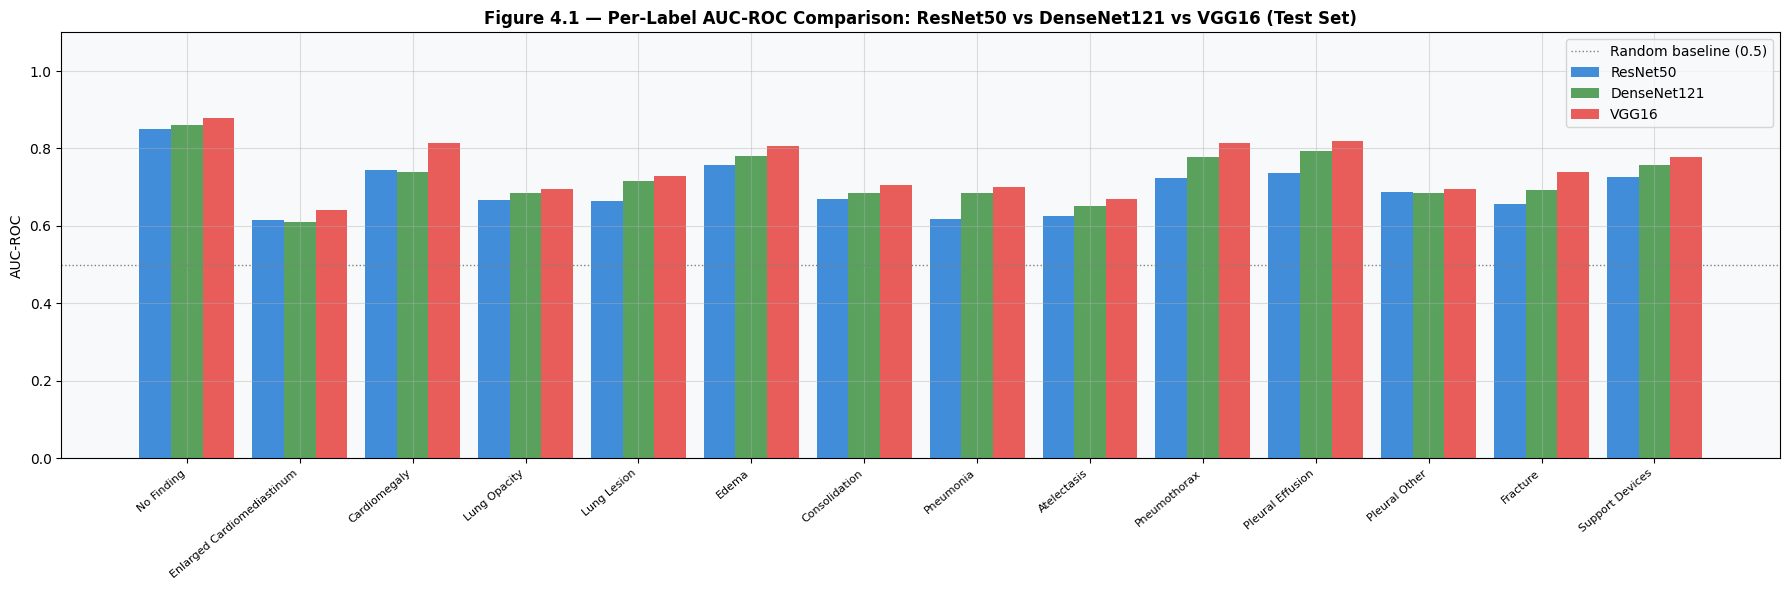

Saved: fig_nb4_grouped_bar.png


In [5]:
x = np.arange(len(LABEL_COLS))
width = 0.28

fig, ax = plt.subplots(figsize=(18, 6))
for i, (m, label, color) in enumerate(zip(MODELS, MODEL_LABELS, COLORS)):
    vals = [results[m]['auc_test'].get(c, 0) or 0 for c in LABEL_COLS]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=label, color=color, alpha=0.82)

mean_aucs = [results[m]['auc_test']['MEAN_AUC'] for m in MODELS]
ax.axhline(0.5, color='gray', lw=1, linestyle=':', label='Random baseline (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(LABEL_COLS, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.set_title('Figure 4.1 — Per-Label AUC-ROC Comparison: ResNet50 vs DenseNet121 vs VGG16 (Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_nb4_grouped_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nb4_grouped_bar.png')


### 4.2 — Heatmap: AUC-ROC per Label per Model (Test Set)

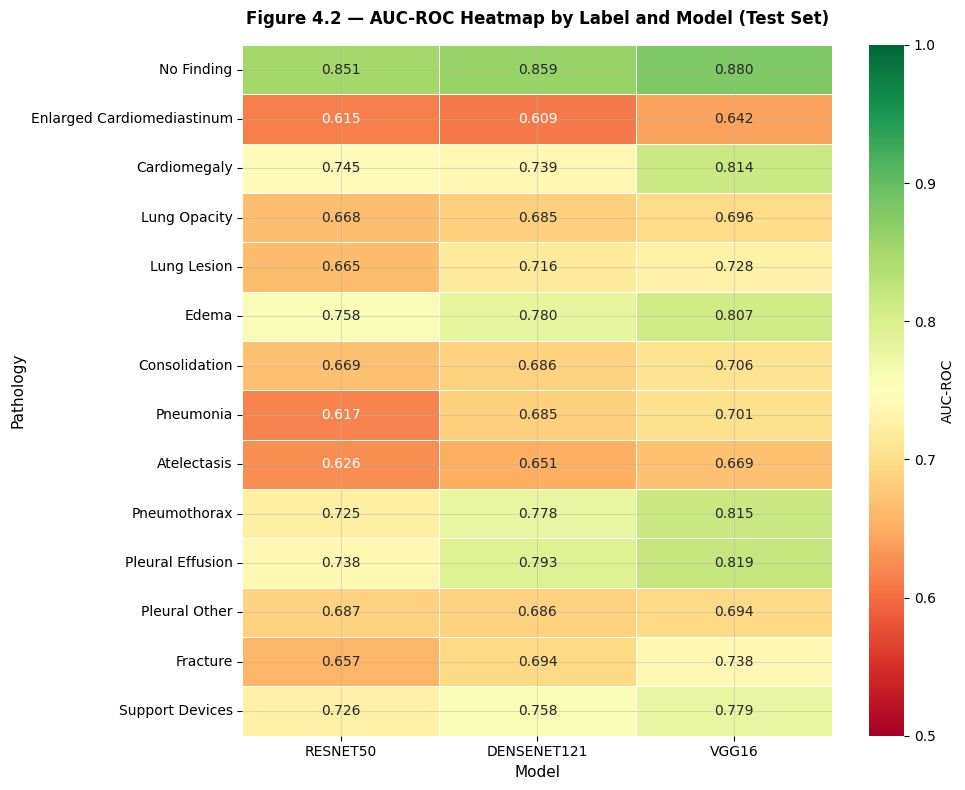

Saved: fig_nb4_heatmap.png


In [6]:
heatmap_data = df_test[LABEL_COLS].T  # rows=labels, cols=models

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heatmap_data.astype(float),
    annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.5, vmax=1.0, linewidths=0.5,
    ax=ax, cbar_kws={'label': 'AUC-ROC'}
)
ax.set_title('Figure 4.2 — AUC-ROC Heatmap by Label and Model (Test Set)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Pathology', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_nb4_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nb4_heatmap.png')


### 4.3 — Mean AUC Summary Bar

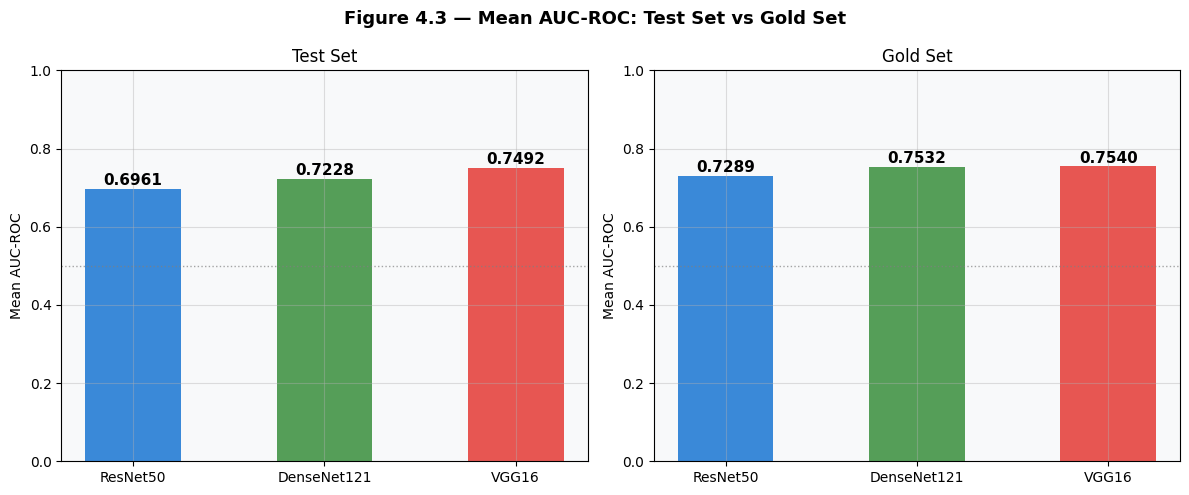

Saved: fig_nb4_mean_auc.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 4.3 — Mean AUC-ROC: Test Set vs Gold Set', fontsize=13, fontweight='bold')

for ax, split in zip(axes, ['test', 'gold']):
    vals = [results[m][f'auc_{split}']['MEAN_AUC'] for m in MODELS]
    bars = ax.bar(MODEL_LABELS, vals, color=COLORS, alpha=0.85, width=0.5)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Mean AUC-ROC')
    ax.set_title(f'{split.capitalize()} Set')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.axhline(0.5, color='gray', lw=1, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_nb4_mean_auc.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nb4_mean_auc.png')


### 4.4 — Radar Chart: Multi-Dimensional Comparison

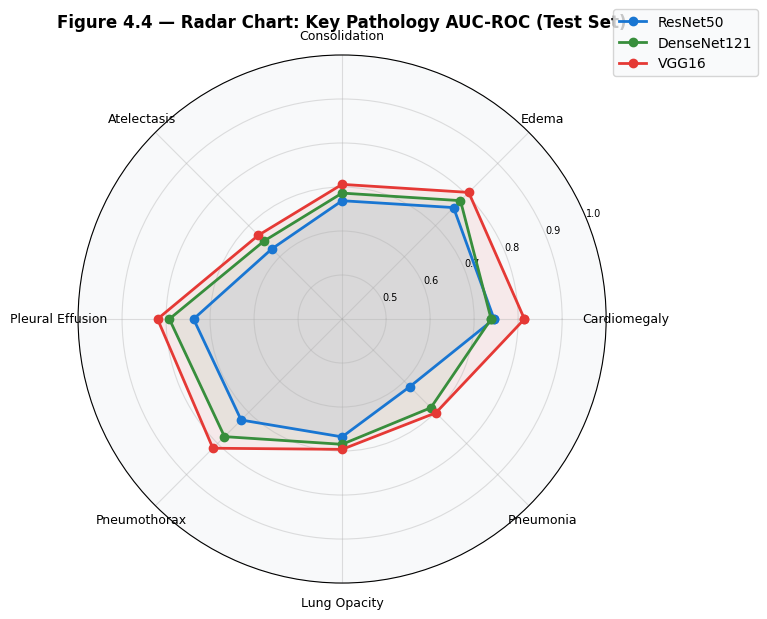

Saved: fig_nb4_radar.png


In [8]:
from matplotlib.patches import FancyBboxPatch
import matplotlib

# Select 8 most clinically relevant labels for radar
radar_labels = ['Cardiomegaly', 'Edema', 'Consolidation', 'Atelectasis',
                'Pleural Effusion', 'Pneumothorax', 'Lung Opacity', 'Pneumonia']
N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

for m, label, color in zip(MODELS, MODEL_LABELS, COLORS):
    vals = [results[m]['auc_test'].get(c, 0) or 0 for c in radar_labels]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=color, label=label)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_ylim(0.4, 1.0)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.5','0.6','0.7','0.8','0.9','1.0'], fontsize=7)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Figure 4.4 — Radar Chart: Key Pathology AUC-ROC (Test Set)',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_nb4_radar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nb4_radar.png')


---
## 5. Statistical Summary

Per-model summary: mean, min, max, and count of labels with AUC ≥ 0.75.

In [9]:
print('=' * 65)
print(f'  {'Model':<15} {'Mean AUC':>10} {'Min AUC':>10} {'Max AUC':>10} {'≥0.75':>8}')
print('-' * 65)
for m, label in zip(MODELS, MODEL_LABELS):
    aucs = [results[m]['auc_test'].get(c) for c in LABEL_COLS]
    aucs = [a for a in aucs if a is not None]
    mean = np.mean(aucs)
    mn   = np.min(aucs)
    mx   = np.max(aucs)
    good = sum(1 for a in aucs if a >= 0.75)
    print(f'  {label:<15} {mean:>10.4f} {mn:>10.4f} {mx:>10.4f} {good:>8}/14')
print('=' * 65)

# Per-label winner
print('\nWinner per label (highest Test AUC):')
print('-' * 45)
for col in LABEL_COLS:
    aucs = {m: (results[m]['auc_test'].get(col) or 0) for m in MODELS}
    winner = max(aucs, key=aucs.get)
    print(f'  {col:<35} → {winner.upper()} ({aucs[winner]:.4f})')


  Model             Mean AUC    Min AUC    Max AUC    ≥0.75
-----------------------------------------------------------------
  ResNet50            0.6961     0.6150     0.8509        2/14
  DenseNet121         0.7228     0.6094     0.8595        5/14
  VGG16               0.7492     0.6417     0.8795        6/14

Winner per label (highest Test AUC):
---------------------------------------------
  No Finding                          → VGG16 (0.8795)
  Enlarged Cardiomediastinum          → VGG16 (0.6417)
  Cardiomegaly                        → VGG16 (0.8143)
  Lung Opacity                        → VGG16 (0.6962)
  Lung Lesion                         → VGG16 (0.7279)
  Edema                               → VGG16 (0.8069)
  Consolidation                       → VGG16 (0.7060)
  Pneumonia                           → VGG16 (0.7014)
  Atelectasis                         → VGG16 (0.6692)
  Pneumothorax                        → VGG16 (0.8152)
  Pleural Effusion                    → VGG16 (0.81

---
## 6. Best Model Selection

Selection criterion: **highest Mean AUC-ROC on the Test Set.**  
The best model will be used for Grad-CAM explainability in Notebook 5.

In [10]:
mean_aucs = {m: results[m]['auc_test']['MEAN_AUC'] for m in MODELS}
BEST_MODEL = max(mean_aucs, key=mean_aucs.get)
BEST_AUC   = mean_aucs[BEST_MODEL]

print('=' * 55)
print('  BEST MODEL SELECTION')
print('=' * 55)
for m, label in zip(MODELS, MODEL_LABELS):
    marker = ' ◄ SELECTED' if m == BEST_MODEL else ''
    print(f'  {label:<15}: Mean AUC = {mean_aucs[m]:.4f}{marker}')
print('=' * 55)
print(f'  Best backbone : {BEST_MODEL.upper()}')
print(f'  Mean AUC      : {BEST_AUC:.4f}')
print(f'  Checkpoint    : /kaggle/working/{BEST_MODEL}_best.h5')
print('=' * 55)

# Save selection for NB5
selection = {
    'best_model': BEST_MODEL,
    'best_auc_test': BEST_AUC,
    'best_auc_gold': results[BEST_MODEL]['auc_gold']['MEAN_AUC'],
    'checkpoint': f'/kaggle/working/{BEST_MODEL}_best.h5',
    'all_mean_aucs': mean_aucs
}
with open(os.path.join(OUT_DIR, 'nb4_best_model.json'), 'w') as f:
    json.dump(selection, f, indent=2)
print('Saved: nb4_best_model.json  (used by NB5)')


  BEST MODEL SELECTION
  ResNet50       : Mean AUC = 0.6961
  DenseNet121    : Mean AUC = 0.7228
  VGG16          : Mean AUC = 0.7492 ◄ SELECTED
  Best backbone : VGG16
  Mean AUC      : 0.7492
  Checkpoint    : /kaggle/working/vgg16_best.h5
Saved: nb4_best_model.json  (used by NB5)


---
## 7. Summary

| | ResNet50 | DenseNet121 | VGG16 |
|---|---|---|---|
| Architecture | Skip connections (residual) | Dense feature reuse | Sequential 3×3 conv |
| Backbone params | ~23M | ~7M | ~138M |
| Unfreeze in P2 | Last 30 layers | Last 80 layers | Block4 + Block5 |
| Uncertainty strategy | U-Mixed | U-Mixed | U-Mixed |
| Label smoothing | ε=0.05 | ε=0.05 | ε=0.05 |

> The selected backbone is passed to **Notebook 5** for Grad-CAM explainability analysis.

---

## References

1. He, K., et al. (2016). **Deep Residual Learning for Image Recognition.** *CVPR*, 770–778.
2. Huang, G., et al. (2017). **Densely Connected Convolutional Networks.** *CVPR*, 4700–4708.
3. Simonyan, K., & Zisserman, A. (2015). **Very Deep Convolutional Networks.** *ICLR.* arXiv:1409.1556.
4. Irvin, J., et al. (2019). **CheXpert.** *AAAI*, 33(01), 590–597.